student_number = "402102392"   
Name = "Niloofar"             
Last_Name = "Mahmoodi"            

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.cm as cm
import pandas as pd
from imblearn.over_sampling import SMOTE

# part 1: kNN classifier
## Question 1(20pts)

In this section, we will implement a kNN classifier from scratch.

In [71]:
# TODO 1.1: Implement the KNNClassifier class from scratch.
class KNNClassifier:
    def __init__(self, k =3, distance_metric='euclidean'):
        self.k= k
        self.distance_model = distance_metric

    def XY(self, X, Y):
        self.Xtrain = np.array(X)
        self.Ytrain = np.array(Y)

    def Distance(self, x1, x2):
        if self.distance_model =='euclidean':
            return np.sqrt(np.sum((x1- x2) ** 2))
        elif self.distance_model== 'manhattan':
            return np.sum(np.abs(x1 - x2))
        elif self.distance_model == 'minkowski':
            return np.sum(np.abs(x1 - x2) ** 3) ** (1 / 3)
        else:
            raise ValueError('Unsupported distance')

    def predict(self, X):
        X = np.array(X)
        predicts =[]
        for x in X:
            distances = np.array([self.Distance(x, x_train) for x_train in self.Xtrain])
            k_i = np.argsort(distances)[:self.k]
            k_label = self.Ytrain[k_i]
            Labels,counts= np.unique(k_label, return_counts=True)
            predicts.append(Labels[np.argmax(counts)])
        return np.array(predicts)

Using the kNN classifier defined, we can apply different distance measures. Let us generate some random sample points:

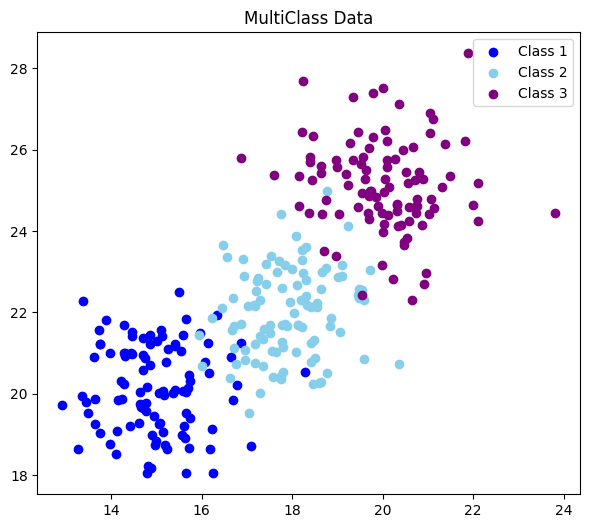

In [72]:
# TODO 1.2: Generate and visualize synthetic multi-class data.
np.random.seed(90)
N_sample = 100
class1 = np.random.randn(N_sample, 2)+[15, 20]
class2 = np.random.randn(N_sample, 2)+[18, 22]
class3 = np.random.randn(N_sample, 2)+[20, 25]

X = np.vstack((class1,class2, class3))
Y = np.array([0] *N_sample + [1] * N_sample + [2] * N_sample)

plt.figure(figsize=(7, 6))
plt.scatter(class1[:,0], class1[:, 1], color='blue', label='Class 1')
plt.scatter(class2[:, 0], class2[:,1], color='skyblue', label='Class 2')
plt.scatter(class3[:, 0],class3[:, 1], color='purple', label='Class 3')
plt.title('MultiClass Data')
plt.legend()
plt.show()


Find the training and test samples below.

In [73]:
# TODO 1.3: Split the synthetic data into training and test sets.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    X, Y, random_state=90, stratify=Y
)
print("Xtrain.shape =",Xtrain.shape)
print("Xtest.shape  =", Xtest.shape)    
print("Ytrain.shape=", Ytrain.shape)   
print("Ytest.shape  =", Ytest.shape)    

Xtrain.shape = (225, 2)
Xtest.shape  = (75, 2)
Ytrain.shape= (225,)
Ytest.shape  = (75,)


## Question 2(20pts)
Define three distance methods:

<span style="color:pink">Explain each one briefly.</span>

In [74]:
# TODO 2.1: Define Euclidean, Manhattan, and Minkowski distance functions.
def euclidean_distance(x1,x2):
    return np.sqrt(np.sum((x1-x2) ** 2))

def manhattan_distance(x1,x2):
    return np.sum(np.abs(x1-x2))

def minkowski_distance(x1,x2):
    return np.sum(np.abs(x1 -x2) **3) ** (1 /3)

Let's visualize:

In [75]:
# TODO 2.2: Implement a function to plot kNN decision boundaries.
def KNN_boundary(model, X, y, R=0.1):
    x1_Min, x1_Max = X[:,0].min() - 1, X[:, 0].max() + 1
    x2_Min,x2_Max = X[:, 1].min() - 1,X[:, 1].max() +1
    xx1, xx2 = np.meshgrid(np.arange(x1_Min, x1_Max, R), np.arange(x2_Min, x2_Max, R))
    
    m = model.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    m = m.reshape(xx1.shape)
    
    plt.contourf(xx1,xx2,m,alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5], colors=['blue', 'skyblue', 'purple'])
    plt.scatter(class1[:, 0], class1[:, 1], color='blue', edgecolor='k',label='Class 1')
    plt.scatter(class2[:,0], class2[:, 1], color='skyblue', edgecolor='k', label='Class 2')
    plt.scatter(class3[:, 0], class3[:,1], color='purple', edgecolor='k', label='Class 3')

    plt.title('KNN Decision Boundary')
    plt.legend()

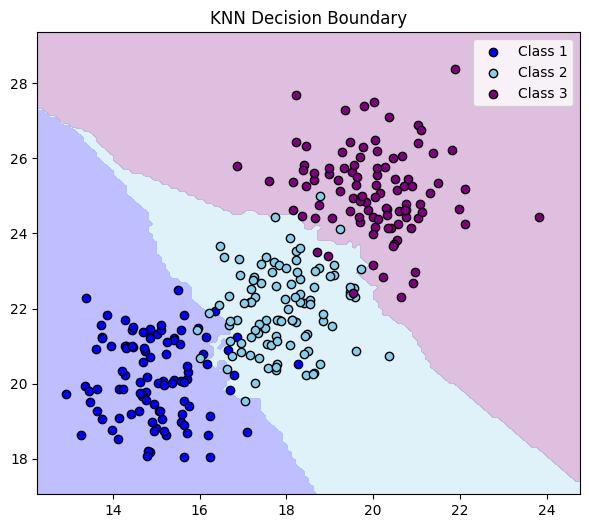

In [76]:
# TODO 2.3: Fit kNN with a chosen k and visualize the decision boundary.
D_model = KNNClassifier(k=5, distance_metric='euclidean')
D_model.XY(Xtrain, Ytrain)
plt.figure(figsize =(7, 6))
KNN_boundary(D_model, Xtrain,Ytrain)
plt.show()

## Question 3(20pts)
Plot the accuracy based on k values.
* Perform this for all the distance functions you defined earlier (Euclidean, Manhattan, and Minkowski).

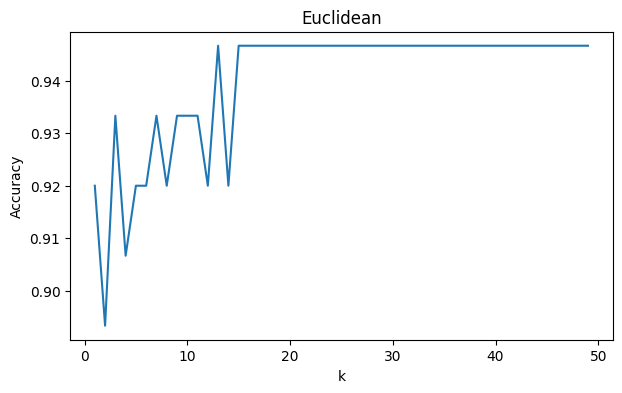

In [90]:
# TODO 3.1: Plot accuracy versus k for Euclidean distance.
k_values = range(1, 50)
Accuracy_euclidean = []

for k in k_values:
    model = KNNClassifier(k=k, distance_metric='euclidean')
    model.XY(Xtrain, Ytrain)
    Ypredict = model.predict(Xtest)
    Accuracy_euclidean.append(accuracy_score(Ytest, Ypredict))

plt.figure(figsize=(7, 4))
plt.plot(k_values, Accuracy_euclidean)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Euclidean')
plt.show()

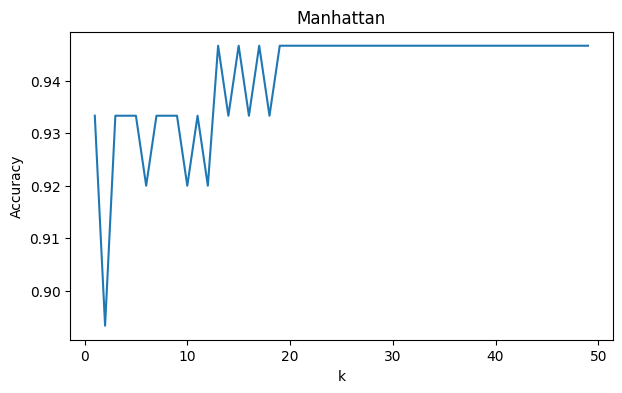

In [91]:
# TODO 3.2: Plot accuracy versus k for Manhattan distance.
Accuracy_manhattan = []

for k in k_values:
    model = KNNClassifier(k=k, distance_metric='manhattan')
    model.XY(Xtrain, Ytrain)
    Ypredict =model.predict(Xtest)
    Accuracy_manhattan.append(accuracy_score(Ytest, Ypredict))

plt.figure(figsize=(7,4))
plt.plot(k_values, Accuracy_manhattan)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Manhattan')
plt.show()


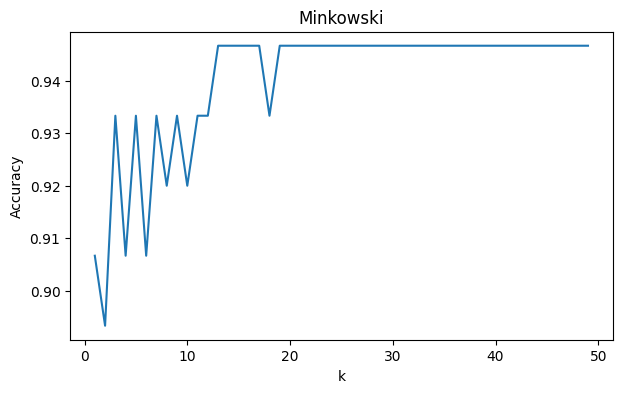

In [92]:
# TODO 3.3: Plot accuracy versus k for Minkowski distance.
Accuracy_minkowski = []

for k in k_values:
    model = KNNClassifier(k=k, distance_metric='minkowski')
    model.XY(Xtrain,Ytrain)
    Ypredict =model.predict(Xtest)
    Accuracy_minkowski.append(accuracy_score(Ytest, Ypredict))

plt.figure(figsize=(7,4))
plt.plot(k_values,Accuracy_minkowski)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Minkowski')
plt.show()

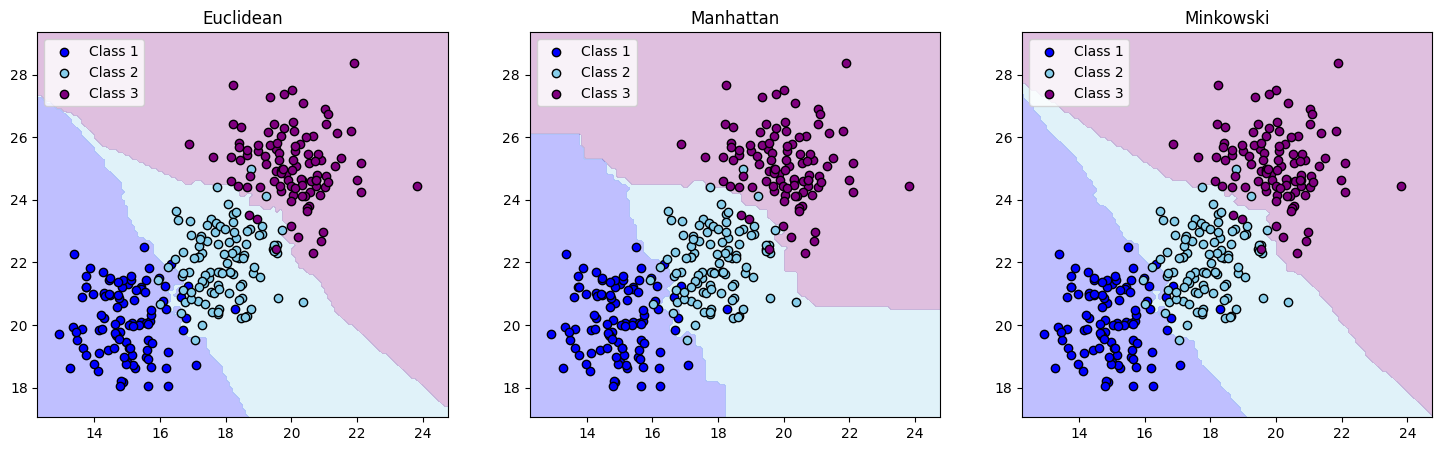

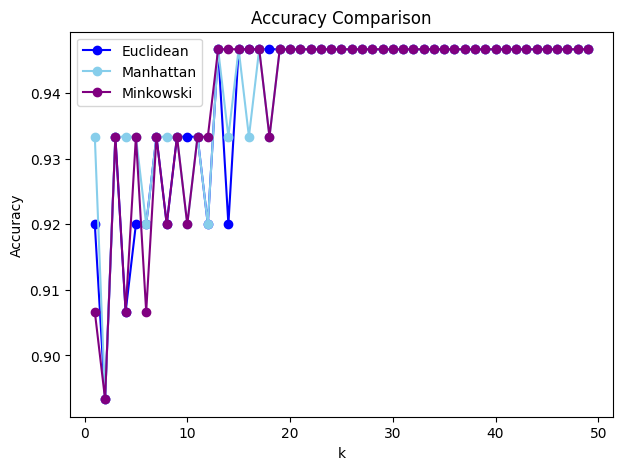

In [93]:
# TODO 3.4: Compare decision boundaries and accuracy curves for all distance functions.
model1 = KNNClassifier(k=5, distance_metric='euclidean')
model1.XY(Xtrain, Ytrain)
model2 = KNNClassifier(k=5,distance_metric='manhattan')
model2.XY(Xtrain, Ytrain)
model3 = KNNClassifier(k=5,distance_metric='minkowski')
model3.XY(Xtrain, Ytrain)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
KNN_boundary(model1, Xtrain, Ytrain, R=0.1)
plt.title('Euclidean')

plt.subplot(1, 3, 2)
KNN_boundary(model2, Xtrain, Ytrain, R=0.1)
plt.title('Manhattan')

plt.subplot(1, 3, 3)
KNN_boundary(model3, Xtrain, Ytrain, R=0.1)
plt.title('Minkowski')
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(k_values,Accuracy_euclidean, marker='o', color='blue', label='Euclidean')
plt.plot(k_values, Accuracy_manhattan, marker='o', color='skyblue',label='Manhattan')
plt.plot(k_values, Accuracy_minkowski, marker='o', color='purple',label='Minkowski')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.legend()
plt.show()

# part 2: The Loan Dataset
## Question 4(20pts)

1. Seperate dependent features (Loan_Status) from independent features.

In [115]:
# TODO 4.1: Load the Loan dataset and inspect its first rows.
loan_dataset = pd.read_csv('Loan.csv')
if 'Unnamed: 0' in loan_dataset.columns:
    loan_dataset = loan_dataset.drop('Unnamed: 0',axis=1)
loan_dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,146.412162,360.0,1,1,1
1,1,1,1,1,0,4583,1508.0,128.000000,360.0,1,0,0
2,1,1,0,1,1,3000,0.0,66.000000,360.0,1,1,1
3,1,1,0,0,0,2583,2358.0,120.000000,360.0,1,1,1
4,1,0,0,1,0,6000,0.0,141.000000,360.0,1,1,1


2. Seperate dependent features (Loan_Status) from independent features.

In [117]:
# TODO 4.2: Print the categories or unique values for each feature.
X = loan_dataset.drop('Loan_Status',axis=1)
Y = loan_dataset['Loan_Status']

print("\nUnique values for each feature:")
for i in loan_dataset.columns:
    print("Feature:", i)
    print(loan_dataset[i].unique())


Unique values for each feature:
Feature: Gender
[1 0]
Feature: Married
[0 1]
Feature: Dependents
[0 1 2 3]
Feature: Education
[1 0]
Feature: Self_Employed
[0 1]
Feature: ApplicantIncome
[ 5849  4583  3000  2583  6000  5417  2333  3036  4006  3200  2500  3073
  1853  4950  3596  3510  4887  2600  7660  5955  3365  3717  9560  2799
  4226  1442  3750  4166  3167  4692  3500 12500  2275  1828  3667  3748
  3600  1800  2400  3941  4695  3410  5649  5821  2645  4000  1928  3086
  4230  4616 11500  2708  2132  3366  8080  3357  3029  4945  5726 10750
  4300  3208  1875  4755  5266  1000  3333  3846  2395  1378  3988  2366
  8566  5695  2958  3273  4133  6782  2484  1977  1759  4843 13650  4652
  3816  3052 11417  7333  3800  5316  2929  3572  7451  5050  2214  5568
 10408  5667  2137  2957  3692  3865  6080  2014  2718  4895  3316 14999
  4200  5042  2698  2330 14866  1538 10000  4860  6277  2577  9166  2281
  3254  9538  2980  1863  7933  3089  4167  3707  2439  8000  1820  5708
  4344  34

3. Normalize the data to the range of independent variables or features of data.

In [126]:
# TODO 4.3: Normalize the independent numerical features.
Cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X[Cols] = scaler.fit_transform(X[Cols])
print("Normalized independent numerical features:")
X.head()

Normalized independent numerical features:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1.0,0.0,0.000000,1.0,0.0,0.316347,0.000000,0.321808,1.0,1.0,0.5
1,1.0,1.0,0.333333,1.0,0.0,0.246073,0.167929,0.278689,1.0,1.0,0.0
2,1.0,1.0,0.000000,1.0,1.0,0.158201,0.000000,0.133489,1.0,1.0,0.5
3,1.0,1.0,0.000000,0.0,0.0,0.135054,0.262584,0.259953,1.0,1.0,0.5
4,1.0,0.0,0.000000,1.0,0.0,0.324729,0.000000,0.309133,1.0,1.0,0.5


4. Split the data into 80% train and 20% test.

In [128]:
# TODO 4.4: Split the Loan dataset into 80% train and 20% test.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2,random_state=60,stratify=Y)
print("Xtrain shape:",Xtrain.shape)
print("Xtest shape:",Xtest.shape)
print("Ytrain shape:", Ytrain.shape)
print("Ytest shape:", Ytest.shape)

Xtrain shape: (419, 11)
Xtest shape: (105, 11)
Ytrain shape: (419,)
Ytest shape: (105,)


# part 3: Classification

## Question 5(30pts)
### Classification with implemented KNN
Here, you should use your implemented kNN method to classify the dataset. You can choose any distance function and any k value that you prefer.

Plot the accuracy based on k.

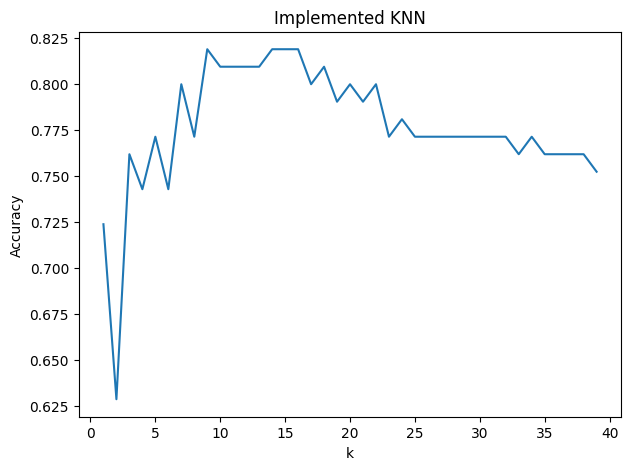

In [134]:
# TODO 5.1: Classify the Loan dataset using your implemented KNN and plot accuracy versus k.
k_values = range(1, 40)
custom_Acc = []

for k in k_values:
    knn_custom =KNNClassifier(k=k,distance_metric='euclidean')
    knn_custom.XY(Xtrain.values, Ytrain.values)   
    y_predict= knn_custom.predict(Xtest.values)
    custom_Acc.append(accuracy_score(Ytest, y_predict))

plt.figure(figsize=(7,5))
plt.plot(k_values, custom_Acc)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Implemented KNN')
plt.show()

Now, use the built-in kNN method in sklearn and plot the accuracy based on k.

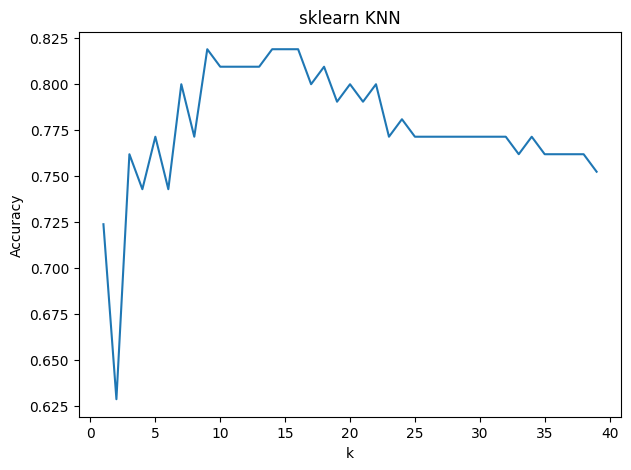

In [136]:
# TODO 5.2: Use sklearn KNeighborsClassifier and plot accuracy versus k.
sklearn_Acc = []

for k in k_values:
    knn_sklearn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_sklearn.fit(Xtrain, Ytrain)
    Y_predict =knn_sklearn.predict(Xtest)
    sklearn_Acc.append(accuracy_score(Ytest, Y_predict))

plt.figure(figsize=(7,5))
plt.plot(k_values,sklearn_Acc)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('sklearn KNN')
plt.show()

Now, use the best k value and find the evaluation metrics. Plot the confusion matrix.

Best k for implemented KNN: 9
Accuracy: 0.819047619047619
Precision: 0.8021978021978022
Recall: 0.9864864864864865
F1-score: 0.8848484848484848


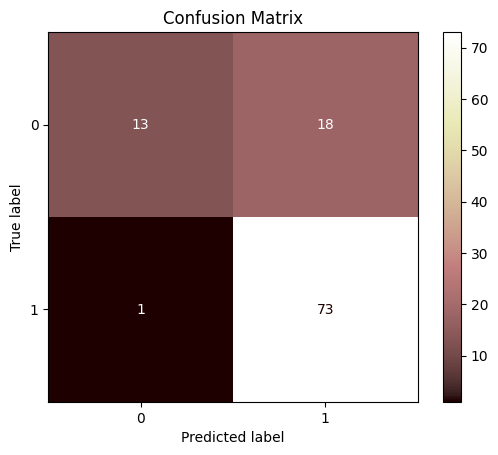

In [147]:
# TODO 5.3: Use the best k, compute evaluation metrics, and plot the confusion matrix.
best_k = k_values[custom_Acc.index(max(custom_Acc))]
print("Best k for implemented KNN:", best_k)
best_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
best_model.fit(Xtrain,Ytrain)
y2 = best_model.predict(Xtest)

Accuracy = accuracy_score(Ytest, y2)
print("Accuracy:", Accuracy)
Confusion_matrix = confusion_matrix(Ytest, y2)
tn, fp, fn, tp = Confusion_matrix.ravel()
precision = tp / (tp + fp) if (tp + fp)!= 0 else 0
recall = tp/ (tp + fn) if(tp + fn) != 0 else 0
f1 = 2 *precision * recall/(precision + recall) if (precision + recall) != 0 else 0
print("Precision:", precision)
print("Recall:",recall)
print("F1-score:",f1)

Matrix = ConfusionMatrixDisplay(confusion_matrix=Confusion_matrix)
Matrix.plot(cmap='pink')
plt.title("Confusion Matrix")
plt.show()

Plot the ROC and PRC curve.

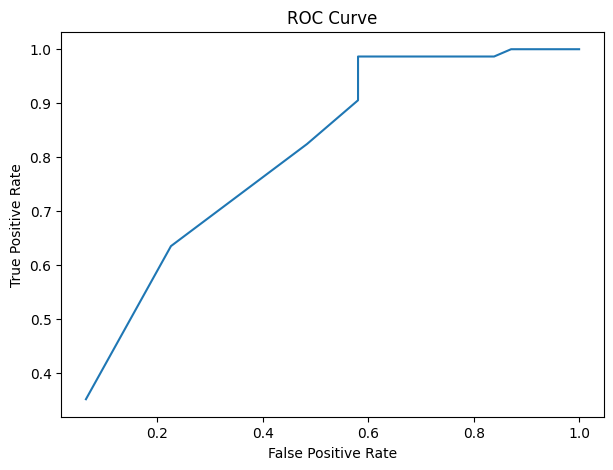

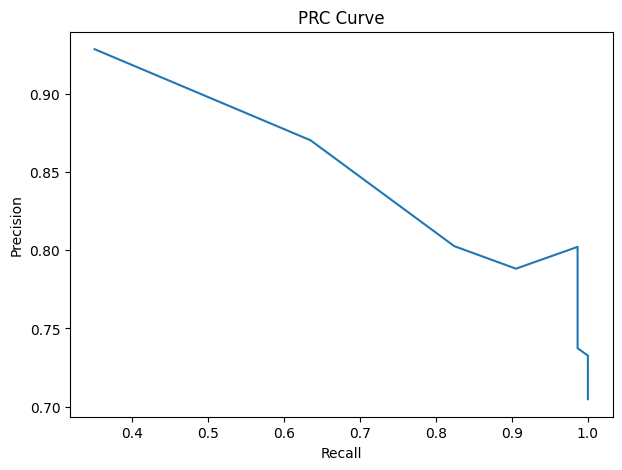

In [155]:
# TODO 5.4: Plot ROC and Precision-Recall curves.
y_prob = best_model.predict_proba(Xtest)[:, 1]
Y_T = np.array(Ytest)
y_scores = np.array(y_prob)
thresholds = np.sort(np.unique(y_scores))[::-1]

TP_L = []
FP_L = []
Precision_L = []
Recall_L = []
for i in thresholds:
    Y_Predict_T= (y_scores >= i).astype(int)
    tp = np.sum((Y_T == 1) & (Y_Predict_T == 1))
    tn = np.sum((Y_T == 0) & (Y_Predict_T== 0))
    fp = np.sum((Y_T== 0) & (Y_Predict_T == 1))
    fn = np.sum((Y_T == 1) & (Y_Predict_T== 0))

    TP = tp / (tp + fn) if (tp + fn) != 0 else 0
    FP = fp /(fp + tn) if (fp + tn) != 0 else 0
    Precision= tp / (tp + fp) if (tp +fp) != 0 else 1
    Recall = tp/ (tp + fn) if (tp + fn)!= 0 else 0
    TP_L.append(TP)
    FP_L.append(FP)
    Precision_L.append(Precision)
    Recall_L.append(Recall)

plt.figure(figsize=(7, 5))
plt.plot(FP_L, TP_L)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(Recall_L,Precision_L)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PRC Curve')
plt.show()


* <span style="color:pink">Compare your implemented kNN method with the built-in one from sklearn.</span>
* <span style="color:pink">Explain the difference of ROC and PRC curve.</span>

#### مقایسه KNN با sklearn
<div dir="rtl" align="right">

kNN دستی و KNeighborsClassifier هر دو بر اساس نزدیک‌ترین همسایه‌ها کلاس را پیش‌ بینی می‌ کنند.
اما نسخه‌ ی sklearn سریع‌ تر و بهینه‌ تر است.
پیاده‌ سازی دستی برای فهم بهتر الگوریتم مفید است ولی معمولا کندتر است.
اگر k و distance یکسان باشند نتایج معمولاً شبیه هم می‌ شوند.
</div>

#### تفاوت ROC و PRC
<div dir="rtl" align="right">
منحنی ROC رابطه‌ ی بین نرخ تشخیص درست کلاس مثبت و نرخ تشخیص اشتباه کلاس منفی را نشان می‌ دهد.
منحنی PRC رابطه‌ ی بین Precision و Recall را نشان می‌ دهد.
ROC برای بررسی کلی مدل مناسب است ولی PRC برای داده‌های نامتعادل کاربردی‌ تر است یعنی زمانی که تعداد نمونه های یک کلاس خیلی کمتر از یک کلاس دیگر باشد.
</div>

## Question 6(10pts)
In previous section, it can be seen that the number between approved and rejected loan is **imbalanced**. In this section, oversampling technique will be used to avoid overfitting.

* You can use 'SMOTE' Technique. 
* <span style="color:pink">Explain the technique that you've used for oversmapling.</span>

Before SMOTE:
Loan_Status
1    295
0    124
Name: count, dtype: int64

After SMOTE:
Loan_Status
1    295
0    295
Name: count, dtype: int64

Evaluation after SMOTE:
Accuracy: 0.6952380952380952
Precision: 0.7837837837837838
Recall: 0.7837837837837838
F1-score: 0.7837837837837838


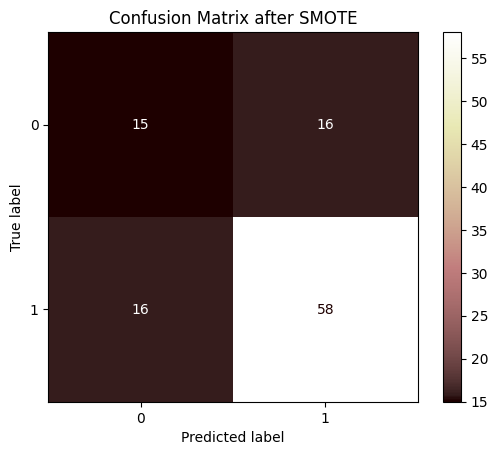

In [157]:
# TODO 6.1: Apply an oversampling method such as SMOTE and evaluate the model.
print("Before SMOTE:")

if isinstance(Ytrain, pd.Series):
    print(Ytrain.value_counts())
else:
    print(np.bincount(Ytrain))

smote= SMOTE(random_state=60)
Xtrain_smote, Ytrain_smote = smote.fit_resample(Xtrain, Ytrain)
print("\nAfter SMOTE:")

if isinstance(Ytrain_smote, pd.Series):
    print(Ytrain_smote.value_counts())
else:
    print(np.bincount(Ytrain_smote))

model_smote = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
model_smote.fit(Xtrain_smote, Ytrain_smote)
Y_Predict_smote = model_smote.predict(Xtest)

Accuracy_smote = accuracy_score(Ytest, Y_Predict_smote)
Confusion_Matrix_smote = confusion_matrix(Ytest, Y_Predict_smote)
tn, fp, fn,tp= Confusion_Matrix_smote.ravel()
precision_smote =tp / (tp + fp) if (tp + fp)!= 0 else 0
recall_smote= tp / (tp + fn) if (tp + fn) != 0 else 0
f1_smote = 2* precision_smote * recall_smote/ (precision_smote + recall_smote) if (precision_smote + recall_smote) != 0 else 0

print("\nEvaluation after SMOTE:")
print("Accuracy:", Accuracy_smote)
print("Precision:", precision_smote)
print("Recall:", recall_smote)
print("F1-score:", f1_smote)

Matrix_smote = ConfusionMatrixDisplay(confusion_matrix=Confusion_Matrix_smote)
Matrix_smote.plot(cmap= 'pink')
plt.title("Confusion Matrix after SMOTE")
plt.show()

### Explain the technique that you've used for oversmapling
<div dir="rtl" align="right">
روش SMOTE برای حل مشکل نامتوازن بودن کلاس‌ ها استفاده می‌ شود.
این روش به جای اینکه فقط نمونه‌ های کلاس کم‌ تر را تکرار کند نمونه‌ های جدید مصنوعی می‌ سازد.
SMOTE بین نمونه‌ های نزدیک از کلاسی که کمتر است نقطه‌ های جدید تولید می‌ کند تا تعداد داده‌ های کلاس‌ ها متعادل‌ تر شود.
این کار باعث می‌ شود مدل فقط به سمت کلاس اکثریت متمایل نشود.
</div>

## Question 7(bonus)(10pts)
Now, use the built-in kNN method in sklearn and plot the accuracy based on k. Then, use the best k value. PLot the ROC and PRC curve.

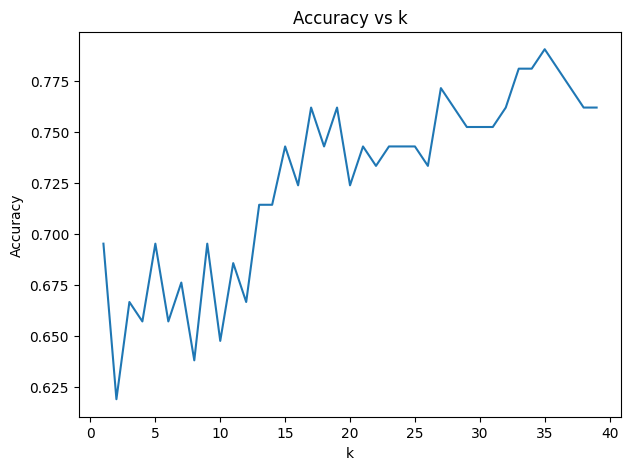

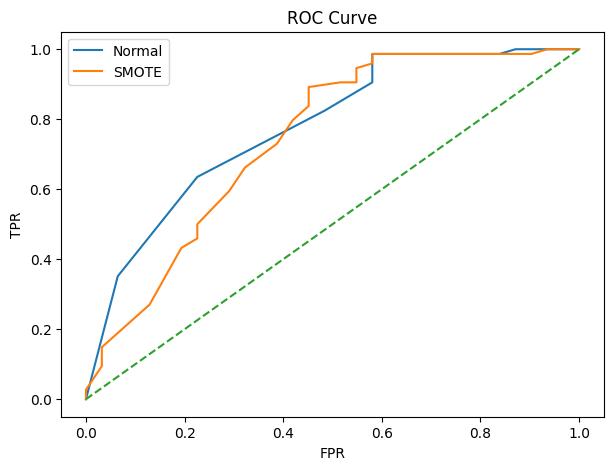

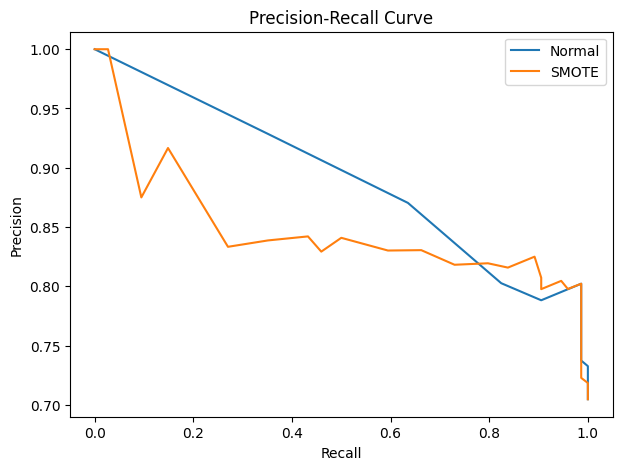

In [171]:
# TODO 7.1: Train sklearn KNN after oversampling, choose the best k, and plot ROC/PRC curves.
k_list = []
Accuracy_normal= []
Accuracy_smote = []

for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtrain, Ytrain)
    Y_predict = knn.predict(Xtest)
    Accuracy_normal.append(np.mean(Y_predict== Ytest))
    knn.fit(Xtrain_smote, Ytrain_smote)
    Y_predict = knn.predict(Xtest)
    Accuracy_smote.append(np.mean(Y_predict == Ytest))
    k_list.append(k)

plt.figure(figsize=(7,5))
plt.plot(k_list, Accuracy_smote)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy vs k')
plt.show()

best_k_normal = k_list[np.argmax(Accuracy_normal)]
best_k_smote = k_list[np.argmax(Accuracy_smote)]
knn_normal = KNeighborsClassifier(n_neighbors= best_k_normal)
knn_normal.fit(Xtrain, Ytrain)
knn_smote= KNeighborsClassifier(n_neighbors=best_k_smote)
knn_smote.fit(Xtrain_smote, Ytrain_smote)
y_score_normal= knn_normal.predict_proba(Xtest)[:,1]
y_score_smote = knn_smote.predict_proba(Xtest)[:,1]
fpr_normal, tpr_normal, _ = roc_curve(Ytest, y_score_normal)
fpr_smote,tpr_smote, _ = roc_curve(Ytest,y_score_smote)

plt.figure(figsize=(7,5))
plt.plot(fpr_normal, tpr_normal, label='Normal')
plt.plot(fpr_smote, tpr_smote, label='SMOTE')
plt.plot([0,1], [0,1], '--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

precision_normal, recall_normal, _ = precision_recall_curve(Ytest, y_score_normal)
precision_smote, recall_smote, _ = precision_recall_curve(Ytest, y_score_smote)

plt.figure(figsize=(7,5))
plt.plot(recall_normal, precision_normal, label='Normal')
plt.plot(recall_smote, precision_smote, label='SMOTE')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


* <span style="color:pink">Compare the ROC and PRC of curve of the model befor and after oversampling.</span>

<div dir="rtl" align="right">
بعد از استفاده از SMOTE تعداد نمونه‌ های کلاس اقلیت بیشتر و داده‌ ها متعادل‌ تر شدند.
در نتیجه مدل توانست نمونه‌ های کلاس اقلیت را بهتر یاد بگیرد.

در ROC Curve معمولا بعد از oversampling منحنی بهتر می‌ شود، چون مدل قدرت تفکیک بهتری بین دو کلاس پیدا می‌ کند.

در PRC Curve هم معمولا بهبود واضح‌ تری دیده می‌ شود چون این نمودار نسبت به کلاس نامتوازن حساس‌ تر است و عملکرد مدل روی کلاس مثبت را بهتر نشان می‌ دهد.

به طور کلی اگر بعد از SMOTE منحنی ROC و مخصوصا PRC بالاتر قرار بگیرند یعنی oversampling به بهبود عملکرد مدل کمک کرده است.
</div>